# 分子系統解析入門３　〜GPCR ファミリーの系統樹を作ろう〜

## 概要
ヒトの **Gタンパク質共役受容体（GPCR）25種** の系統樹を推定します。巨大な受容体スーパーファミリーの進化を読み解いてみましょう。

cytochrome bと一番大きく違う点は**配列の長さが大きくバラついている**点です。この違いが解析手法の選び方にどう影響するか考えながら解析を進めます。

1. **入門編** — Python だけで完結するアプローチ（ペアワイズアラインメント+近隣結合法）で大まかな関係をつかむ
2. **本格編** — **MAFFT** で多重整列し、**IQ-TREE** で最尤系統樹を推定
3. **発展編** — **立体構造**（AlphaFold モデル）を直接重ね合わせて、**構造に基づく系統樹**を作り、アミノ酸配列の系統樹と比べる

### GPCR とは

Gタンパク質共役受容体（G Protein-Coupled Receptor, GPCR）は、細胞膜を **7回貫通** する受容体ファミリーです（参考：[GPCRdb](https://gpcrdb.org/) ）。

- 光・におい・ホルモン・神経伝達物質など、外界の多様なシグナルを細胞内に伝える「アンテナ」
- ヒトゲノムに **約 800 種** が存在し、現在の医薬品の **およそ 1/3** がこのファミリーを標的にする
- すべて「7回膜貫通」という共通の骨格を持つが、配列としては大きく分岐している

GPCRいくつかのクラスに分けられます（GRAFS分類などが有名）。このデータセットには代表的な4クラスが含まれています。

| クラス | 別名 | 例 | 特徴 |
| --- | --- | --- | --- |
| **A** | Rhodopsin 様 | ロドプシン、アドレナリン受容体、ドーパミン受容体 | 最大のグループ(ヒト GPCR の約 85%)。膜貫通領域以外は短め |
| **B** | Secretin 様 | グルカゴン受容体、GLP-1 受容体 | ペプチドホルモンを受容。大きな細胞外ドメインを持つ |
| **C** | Glutamate 様 | 代謝型グルタミン酸受容体、カルシウム感知受容体 | 非常に大きな細胞外ドメインでリガンドを捕まえる |
| **F** | Frizzled | Smoothened、Frizzled-1 | Wnt/Hedgehog シグナル。発生に重要 |

### ライセンス
- 配列・構造データ：UniProt/NCBI/AlphaFold DB のパブリックデータ（`gpcr/gpcr_list.tsv` 参照）

## 0. 必要ライブラリのインストール(初回のみ)

Python パッケージをインストールします。

- `biopython` : 配列解析と系統樹計算
- `matplotlib-fontja` : 日本語フォント
- `ete3` + `PyQt5` : 系統樹の描画(このノートブックの樹はすべて ETE3 で描きます)

**MAFFT と IQ-TREE は別途インストールが必要です(後のセクション 10 で扱います)。**

> Note: ETE3 は内部で Qt を使って樹を画像に描き出します。画面のないサーバーや Colab で動かす場合は、
> 次のセルで環境変数 `QT_QPA_PLATFORM=offscreen` を設定して **ヘッドレス描画** に切り替えます。

In [1]:
%pip install biopython pandas numpy matplotlib seaborn matplotlib-fontja ete3 PyQt5

Note: you may need to restart the kernel to use updated packages.


## 1. ライブラリの読み込みと日本語フォントの設定

グラフに日本語を出すために `matplotlib-fontja` を使います。
**順序が重要**:seaborn のスタイル設定を先に行い、その後に `matplotlib_fontja` を読み込みます。

In [2]:
import os
import sys
import shutil
import tempfile
import subprocess
import warnings
from pathlib import Path

# ETE3 はヘッドレス環境(画面なしのサーバー・Colab)でも描画できるよう、
# Qt のインポートより前に offscreen プラットフォームを指定しておく
os.environ.setdefault("QT_QPA_PLATFORM", "offscreen")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.patches import Patch
import seaborn as sns

from Bio import SeqIO, AlignIO, Phylo
from Bio.Align import PairwiseAligner, substitution_matrices
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor

# 系統樹の描画は ETE3 で行う
from ete3 import Tree as EteTree, TreeStyle, TextFace, NodeStyle, RectFace
from IPython.display import Image as IPyImage, display

# 日本語フォントの設定(順序が重要)
sns.set_style("whitegrid")
print("kernel python :", sys.executable)
try:
    import matplotlib_fontja  # noqa: F401
    _sans = [f for f in plt.rcParams["font.sans-serif"] if f != "IPAexGothic"]
    plt.rcParams["font.sans-serif"] = ["IPAexGothic"] + _sans
    print("matplotlib-fontja: OK")
except ImportError:
    print("matplotlib-fontja が見つかりません。上のセルでインストールしてください。")
plt.rcParams["axes.unicode_minus"] = False

# ETE3 の TextFace 用フォント(CJK を含むものを指定。ラテン文字も問題なく表示できる)
JP_FONT = "Noto Sans CJK JP"

kernel python : /home/qm/claude/lecture/ml/.venv/bin/python
matplotlib-fontja: OK


## 2. FASTA ファイルの読み込み

**FASTA** は配列データを表す最も基本的なテキスト形式です。今回はアミノ酸配列(1文字コード)です。

```
>RHO|P08100|ClassA|Rhodopsin|RefSeq:NP_000530.1   ← ヘッダー(`>` で始まる)
MNGTEGPNFYVPFSNATGVVRSPFEYPQYYLAEPWQFSMLAAYMFLLI...  ← 配列本体(20種類のアミノ酸)
```

ヘッダーは `>遺伝子名|UniProt番号|クラス|説明|RefSeq` を `|` で区切った形式です。
ここから **遺伝子名** を ID として取り出し、**クラス** をあとで色分けに使います。

In [3]:
# データファイルへのパス(実行ディレクトリの違いに強いよう自動検出)
def _find_dir(candidates):
    for c in candidates:
        if Path(c).exists():
            return Path(c)
    raise FileNotFoundError(f"gpcr フォルダが見つかりません。候補: {candidates}")

GPCR_DIR = _find_dir(["gpcr", "../gpcr", "phylogenetics/gpcr"])
FASTA_PATH = GPCR_DIR / "all_GPCRs.fasta"
LIST_PATH = GPCR_DIR / "gpcr_list.tsv"
PDB_DIR = GPCR_DIR / "pdb"

# MAFFT / IQ-TREE 用の作業ディレクトリ
WORK_DIR = Path("./phylo_work_gpcr")
WORK_DIR.mkdir(exist_ok=True)

for p in [FASTA_PATH, LIST_PATH]:
    assert p.exists(), f"見つかりません: {p}"
print(f"データ準備 OK: {GPCR_DIR.resolve()}")
print(f"作業ディレクトリ: {WORK_DIR.resolve()}")

records = list(SeqIO.parse(FASTA_PATH, "fasta"))
print(f"読み込んだ配列数: {len(records)}")
print(f"最初のヘッダー : {records[0].description}")
print(f"最初の60残基   : {str(records[0].seq)[:60]} ...")

# ヘッダーを分解して「遺伝子名」を ID に、クラスを別途記録
gene_to_class = {}
for rec in records:
    parts = rec.description.split("|")
    gene = parts[0]
    cls = parts[2].replace("Class", "")   # "ClassA" -> "A"
    gene_to_class[gene] = cls
    rec.id = gene
    rec.name = gene
    rec.description = ""

print(f"\n整理後の ID 一覧: {[r.id for r in records]}")

データ準備 OK: /home/qm/claude/lecture/phylogenetics/gpcr
作業ディレクトリ: /home/qm/claude/lecture/phylogenetics/phylo_work_gpcr
読み込んだ配列数: 25
最初のヘッダー : RHO|P08100|ClassA|Rhodopsin|RefSeq:NP_000530.1
最初の60残基   : MNGTEGPNFYVPFSNATGVVRSPFEYPQYYLAEPWQFSMLAAYMFLLIVLGFPINFLTLY ...

整理後の ID 一覧: ['RHO', 'OPN1SW', 'OPN1MW', 'ADRB1', 'ADRB2', 'ADRA1A', 'ADRA2A', 'CHRM1', 'CHRM2', 'DRD1', 'DRD2', 'HTR1A', 'HTR2A', 'HRH1', 'OPRM1', 'CNR1', 'AGTR1', 'CXCR4', 'GCGR', 'GLP1R', 'PTH1R', 'GRM1', 'CASR', 'SMO', 'FZD1']


## 3. メタデータ（遺伝子名・クラス・説明）の読み込み

各受容体の遺伝子名・UniProt 番号・クラス・説明が `gpcr_list.tsv` にまとめられています。

In [4]:
metadata = pd.read_csv(LIST_PATH, sep="\t")
# 先頭が "# Gene" のようにコメント記号付きなので列名を整える
metadata.columns = [c.lstrip("# ").strip() for c in metadata.columns]

print(f"メタデータ行数: {len(metadata)}")
print("\n各クラスの受容体数:")
print(metadata["Class"].value_counts().sort_index())
metadata.head()

メタデータ行数: 25

各クラスの受容体数:
Class
A    18
B     3
C     2
F     2
Name: count, dtype: int64


,Gene,RefSeq_Protein,UniProt,Class,Description
0,RHO,NP_000530.1,P08100,A,Rhodopsin
1,OPN1SW,NP_001699.1,P03999,A,Blue-sensitive opsin
2,OPN1MW,NP_000504.1,P04001,A,Green-sensitive opsin
3,ADRB1,NP_000675.1,P08588,A,Beta-1 adrenergic receptor
4,ADRB2,NP_000015.1,P07550,A,Beta-2 adrenergic receptor


## 4. 配列の長さを確認 — なぜタンパク質では「切り詰め」が使えないか

解析に入る前にデータの状態をチェックします。DNA(cytb)の解析では全配列がほぼ同じ長さ（約1140塩基）だったので「先頭から共通の長さだけ切り出す」という乱暴な近似が許されました。

GPCR ではどうでしょうか？クラスごとに配列長を比べてみましょう。

In [5]:
seq_stats = pd.DataFrame({
    "gene": [r.id for r in records],
    "length": [len(r.seq) for r in records],
})
seq_stats["Class"] = seq_stats["gene"].map(gene_to_class)
seq_stats = seq_stats.merge(metadata[["Gene", "Description"]],
                            left_on="gene", right_on="Gene", how="left").drop(columns="Gene")

print("配列長の統計:")
print(seq_stats["length"].describe().round(1))
print(f"\n最短: {seq_stats.loc[seq_stats['length'].idxmin(), 'gene']} "
      f"({seq_stats['length'].min()} aa)")
print(f"最長: {seq_stats.loc[seq_stats['length'].idxmax(), 'gene']} "
      f"({seq_stats['length'].max()} aa)")
seq_stats.sort_values("length").head()

配列長の統計:
count      25.0
mean      504.4
std       177.6
min       348.0
25%       413.0
50%       465.0
75%       477.0
max      1078.0
Name: length, dtype: float64

最短: RHO (348 aa)
最長: CASR (1078 aa)


,gene,length,Class,Description
0,RHO,348,A,Rhodopsin
1,OPN1SW,348,A,Blue-sensitive opsin
17,CXCR4,352,A,C-X-C chemokine receptor type 4
16,AGTR1,359,A,Type-1 angiotensin II receptor
2,OPN1MW,364,A,Green-sensitive opsin


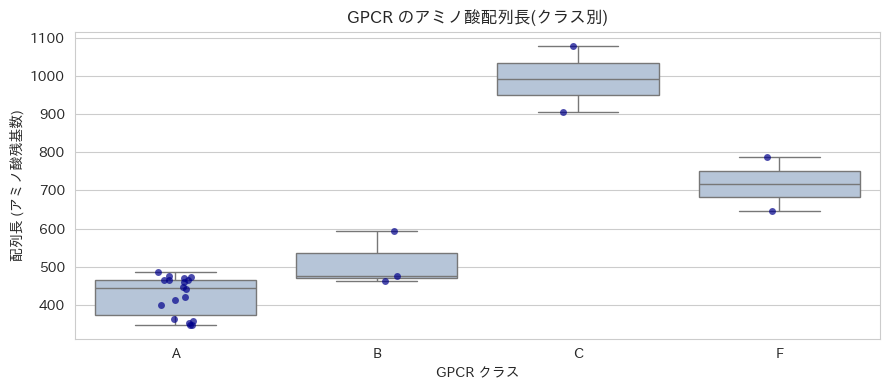

In [6]:
# クラス別の配列長(箱ひげ図 + 個々の点)
class_order = ["A", "B", "C", "F"]
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=seq_stats, x="Class", y="length", order=class_order,
            color="lightsteelblue", ax=ax)
sns.stripplot(data=seq_stats, x="Class", y="length", order=class_order,
              color="darkblue", alpha=0.7, size=5, ax=ax)
ax.set_xlabel("GPCR クラス")
ax.set_ylabel("配列長 (アミノ酸残基数)")
ax.set_title("GPCR のアミノ酸配列長(クラス別)")
plt.tight_layout()
plt.show()

**観察ポイント**

- 配列長は **348 残基(オプシン)から 1078 残基(カルシウム感知受容体)まで** 3 倍以上の開きがある
- クラス **C**（グルタミン酸様）は **巨大な細胞外ドメイン**を持つため特に長い
- 共通しているのは中央の「7回膜貫通領域」だけで、その前後の長さはバラバラ

> つまり先頭からN残基を切り出すと、例えば「ある受容体の膜貫通領域と別の受容体の細胞外ドメインを比べてしまう」ことになり、**まったく無意味な比較**になります。
> このようなケース（実はこちらが一般的）では、同じ進化的起源の残基を縦に揃える操作（=アラインメント）が必須なのです。

## 5. 入門編 — ペアワイズアラインメントで距離行列を作る

多重整列(全配列をいっぺんに揃える)は少し高度なので、入門編ではより素朴な方法を使います。

まず、2配列ずつ「ペアワイズアラインメント」して似ている割合を測り、その「似ていなさ」を距離とします。距離法（NJ法）は距離行列さえあれば系統樹を推定できるので、全配列を一度に揃えなくてもよいのです。ここでは Biopython の `PairwiseAligner` を使い、タンパク質用のスコア表 **BLOSUM62**（似たアミノ酸どうしの置換は軽いペナルティ）で大域アラインメントします。

$$
d(A, B) = 1 - \frac{\text{一致した残基数}}{\text{ギャップを除いた整列長}}
$$

In [7]:
aligner = PairwiseAligner()
aligner.mode = "global"
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -11      # ギャップを開けるペナルティ(BLOSUM62 の標準設定)
aligner.extend_gap_score = -1     # ギャップを伸ばすペナルティ

def identity_distance(s1, s2):
    # 2配列を大域アラインメントし、1 - (%同一性) を距離として返す
    aln = aligner.align(s1, s2)[0]
    a, b = aln[0], aln[1]
    ident = aln_len = 0
    for x, y in zip(a, b):
        if x == "-" or y == "-":
            continue           # ギャップ列は分母から除く
        aln_len += 1
        if x == y:
            ident += 1
    return 1.0 - ident / aln_len if aln_len else 1.0

names = [r.id for r in records]
seqs = {r.id: str(r.seq) for r in records}

print("ペアワイズ距離を計算中(数秒〜十数秒)...")
# Biopython の DistanceMatrix は下三角(対角含む)で持つ
lower = [[0.0] * (i + 1) for i in range(len(names))]
for i in range(len(names)):
    for j in range(i):
        lower[i][j] = identity_distance(seqs[names[i]], seqs[names[j]])
dm = DistanceMatrix(names, lower)
print("完了。距離行列のサイズ:", len(dm.names), "×", len(dm.names))

print("\n例:")
print(f"  RHO vs OPN1SW (どちらもオプシン, クラスA) d = {dm['RHO', 'OPN1SW']:.3f}")
print(f"  ADRB1 vs ADRB2 (β1/β2 アドレナリン受容体) d = {dm['ADRB1', 'ADRB2']:.3f}")
print(f"  RHO vs CASR  (クラスA vs クラスC)        d = {dm['RHO', 'CASR']:.3f}")
print(f"  SMO vs FZD1  (どちらもクラスF)            d = {dm['SMO', 'FZD1']:.3f}")

ペアワイズ距離を計算中(数秒〜十数秒)...
完了。距離行列のサイズ: 25 × 25

例:
  RHO vs OPN1SW (どちらもオプシン, クラスA) d = 0.539
  ADRB1 vs ADRB2 (β1/β2 アドレナリン受容体) d = 0.458
  RHO vs CASR  (クラスA vs クラスC)        d = 0.706
  SMO vs FZD1  (どちらもクラスF)            d = 0.678


## 6. 距離行列をヒートマップで可視化

行と列を **クラス順（A→B→C→F）** に並べると、同じクラスの受容体どうしがうっすらと「ブロック」を形成しているように見えます。

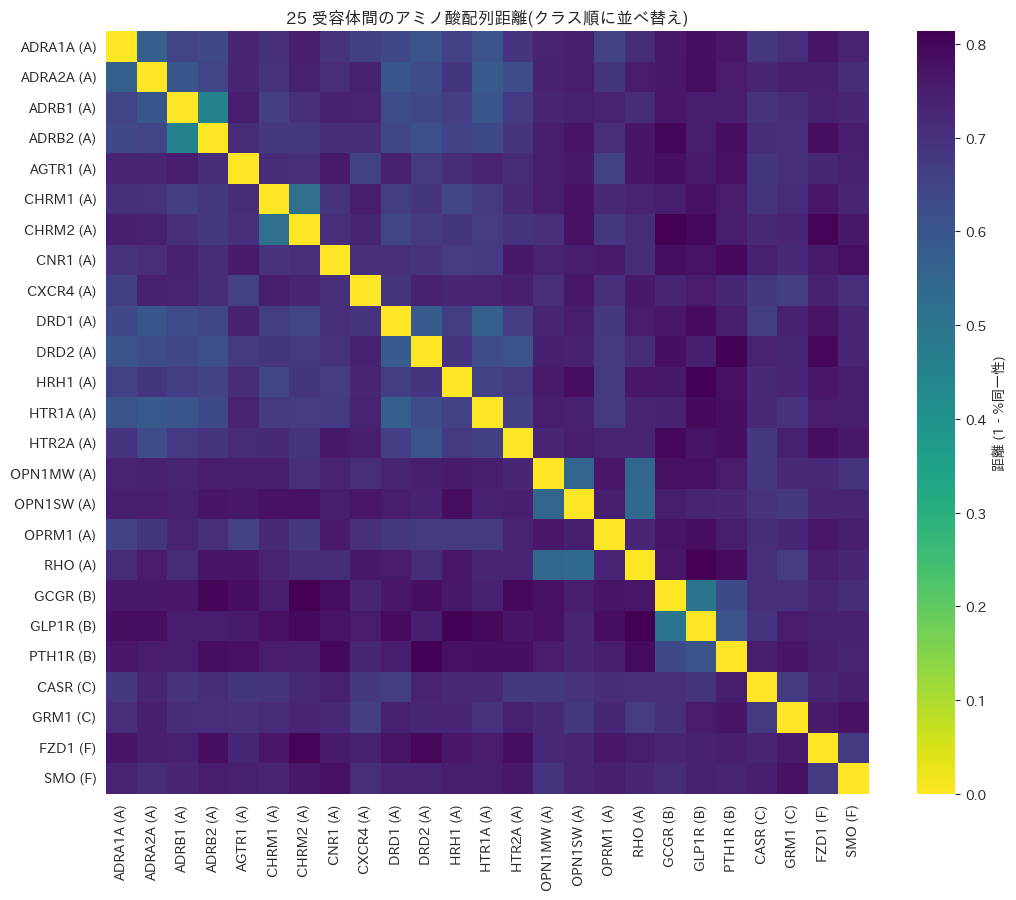

In [8]:
mat = np.array([[dm[a, b] for b in names] for a in names])
dist_df = pd.DataFrame(mat, index=names, columns=names)

# クラス順 → クラス内は遺伝子名順に並べ替え
ordered = sorted(names, key=lambda g: (class_order.index(gene_to_class[g]), g))
dist_df = dist_df.loc[ordered, ordered]

# ラベルに「遺伝子名 (クラス)」を表示
labels = [f"{g} ({gene_to_class[g]})" for g in dist_df.index]

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(dist_df, cmap="viridis_r",
            xticklabels=labels, yticklabels=labels,
            cbar_kws={"label": "距離 (1 - %同一性)"}, ax=ax, square=True)
ax.set_title("25 受容体間のアミノ酸配列距離(クラス順に並べ替え)")
plt.tight_layout()
plt.show()

## 7. 近隣結合法 (NJ法) で系統樹を作る

1_birds.ipynbや2_mammals.ipynbでは明確な **外群** がありましたが、GPCRは4クラスがどれも大きく分岐していて「どれが一番外側の祖先か」が自明ではありません。
そこで今回は **中点ルーティング (midpoint rooting)** ── 最も離れた2葉のちょうど中間を根にする ── を使います。

In [9]:
constructor = DistanceTreeConstructor()
nj_tree = constructor.nj(dm)

# 明確な外群がないので中点で根づけ
nj_tree.root_at_midpoint()

# 内部ノードのデフォルト名(Inner1, ...)はラベル表示の邪魔なので消す
for clade in nj_tree.get_nonterminals():
    clade.name = None

print("NJ 系統樹を作成しました")
print(f"  末端ノード(受容体)の数: {nj_tree.count_terminals()}")

NJ 系統樹を作成しました
  末端ノード(受容体)の数: 25


## 8. 系統樹の描画(クラスで色分け)

系統樹の描画には **ETE3** (`ete3`) を使います。末端ラベル(遺伝子名と説明)を **クラス別の色** で
塗り分け、NJ 樹が GPCR の A/B/C/F クラスをどれくらい再現できているか見てみましょう。

このセルで、以降のすべての樹で使い回す **共通の描画ツールキット**(`bio_to_ete` / `render_ete_to_png` /
`draw_tree_ete`)も定義します。

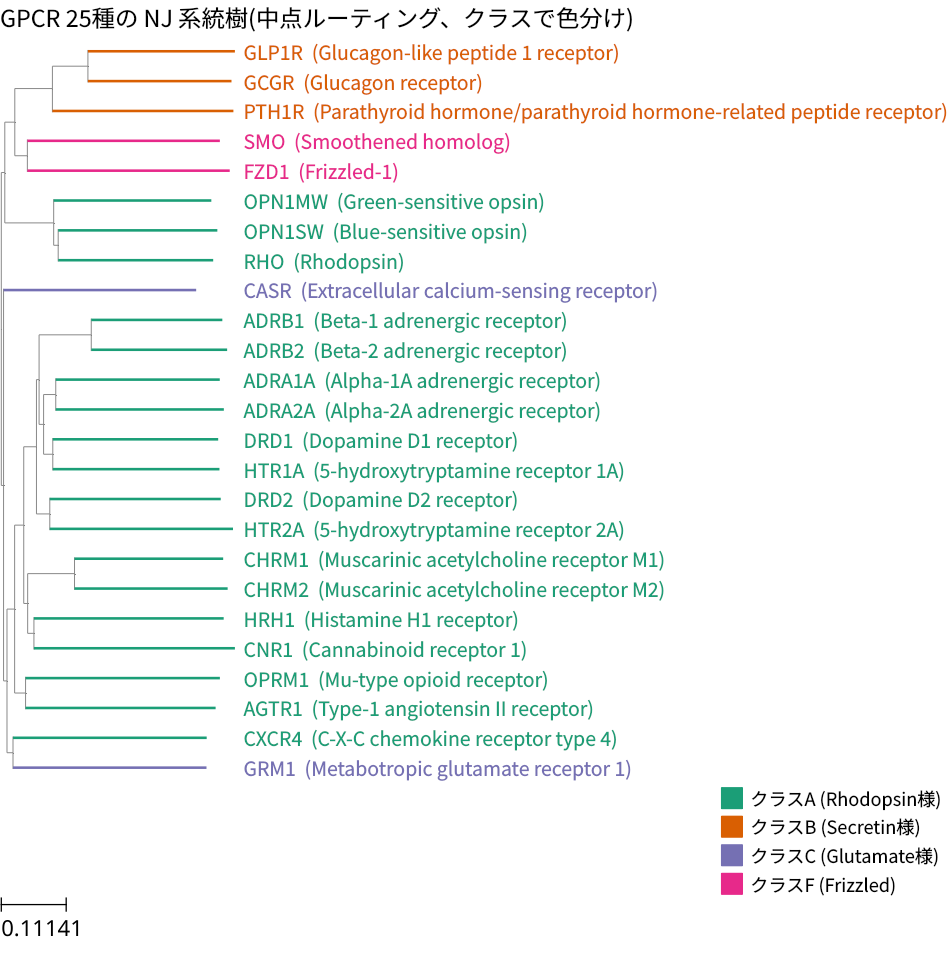

In [10]:
# === クラスごとの色 ===
class_to_color = {
    "A": "#1b9e77",   # 緑(Rhodopsin 様)
    "B": "#d95f02",   # オレンジ(Secretin 様)
    "C": "#7570b3",   # 紫(Glutamate 様)
    "F": "#e7298a",   # ピンク(Frizzled)
}
class_name_ja = {"A": "クラスA (Rhodopsin様)", "B": "クラスB (Secretin様)",
                 "C": "クラスC (Glutamate様)", "F": "クラスF (Frizzled)"}
desc_map = metadata.set_index("Gene")["Description"].to_dict()

def gene_color(gene):
    """遺伝子名 → その GPCR クラスの色"""
    return class_to_color.get(gene_to_class.get(gene, ""), "#000000")

# === ETE3 による系統樹描画ツールキット(以降のすべての樹で使い回す) ===

def bio_to_ete(bio_tree):
    """Biopython の系統樹を ETE3 の Tree に変換する(枝長・ブートストラップ値を引き継ぐ)。

    ルート(一番外側のノード)の枝は描画しないよう dist=0 にしておく。
    """
    def add(bio_clade, ete_node):
        for child in bio_clade.clades:
            n = ete_node.add_child(name=child.name or "",
                                   dist=child.branch_length or 0.0)
            if child.confidence is not None:
                n.support = child.confidence
            add(child, n)
    root = EteTree()
    root.name = bio_tree.root.name or ""
    root.dist = 0.0
    add(bio_tree.root, root)
    return root

def render_ete_to_png(tree, title, show_bootstrap=False, width=950, out_path=None):
    """Biopython 系統樹を ETE3 で描画して PNG に書き出し、ファイルパスを返す。

    - 葉:枝と「遺伝子名(説明)」ラベルを GPCR クラスの色で塗る
    - 内部ノード:show_bootstrap=True ならブートストラップ値を支持率に応じた色で表示
    - タイトルとクラスの凡例も ETE3 上で付与する
    """
    et = bio_to_ete(tree)

    def layout(node):
        if node.is_leaf():
            color = gene_color(node.name)
            ns = NodeStyle(); ns["hz_line_color"] = color
            ns["hz_line_width"] = 2; ns["size"] = 0
            node.set_style(ns)
            desc = desc_map.get(node.name, "")
            label = f"  {node.name}" + (f"  ({desc})" if desc else "")
            node.add_face(TextFace(label, fsize=11, ftype=JP_FONT, fgcolor=color),
                          column=0, position="aligned")
        else:
            ns = NodeStyle(); ns["hz_line_color"] = "#888888"
            ns["vt_line_color"] = "#888888"; ns["size"] = 0
            node.set_style(ns)
            if show_bootstrap and node.support:
                bs = node.support
                bc = "#1b9e77" if bs >= 95 else ("#d95f02" if bs >= 70 else "#b22222")
                node.add_face(TextFace(f"{bs:.0f} ", fsize=8, fgcolor=bc),
                              column=0, position="branch-top")

    ts = TreeStyle()
    ts.show_leaf_name = False
    ts.layout_fn = layout
    ts.show_scale = True
    ts.title.add_face(TextFace(title, fsize=13, ftype=JP_FONT), column=0)
    for k, c in class_to_color.items():
        ts.legend.add_face(RectFace(16, 16, c, c), column=0)
        ts.legend.add_face(TextFace("  " + class_name_ja[k] + "  ", fsize=10, ftype=JP_FONT), column=1)
    if show_bootstrap:
        for lbl, c in [("BS ≥ 95", "#1b9e77"), ("BS 70–94", "#d95f02"), ("BS < 70", "#b22222")]:
            ts.legend.add_face(RectFace(16, 16, c, c), column=0)
            ts.legend.add_face(TextFace("  " + lbl + "  ", fsize=10), column=1)
    ts.legend_position = 4

    if out_path is None:
        out_path = Path(tempfile.gettempdir()) / "ete_tree_gpcr.png"
    et.render(str(out_path), tree_style=ts, w=width, dpi=120)
    return Path(out_path)

def draw_tree_ete(tree, title, show_bootstrap=False, width=950):
    """ETE3 で系統樹を描画し、ノートブックにインライン表示する。"""
    png = render_ete_to_png(tree, title, show_bootstrap=show_bootstrap, width=width)
    display(IPyImage(filename=str(png)))

# 後方互換:既存の呼び出し名(draw_class_tree)を残す(xlabel は ETE3 ではスケールバーが自動表示)
def draw_class_tree(tree, title, xlabel=None):
    draw_tree_ete(tree, title)

# === セクション 8:NJ 系統樹 ===
draw_tree_ete(nj_tree, "GPCR 25種の NJ 系統樹(中点ルーティング、クラスで色分け)")

**観察ポイント**

- クラス **B**(GCGR, GLP1R, PTH1R)・クラス **F**(SMO, FZD1)・クラス **C**(GRM1, CASR)が
  それぞれまとまっていれば、配列だけからクラス分類が再現できたことになる
- クラス **A** の中でも、**オプシン**(RHO/OPN1SW/OPN1MW)や
  **アミン受容体**(ADRB/ADRA/DRD/HTR/CHRM/HRH)が小さな枝でまとまっているはず
- NJ 法は速くて手軽だが、配列が大きく分岐していると一部の枝を取り違えることがある(後で ML 法と比較)

## 9. 本格編 — MAFFT で多重整列し、IQ-TREE で最尤系統樹を推定

### 9.1 MAFFT と IQ-TREE のインストール

環境に応じて以下のいずれかを実行してください(初回のみ)。

```bash
# Google Colab・Ubuntu/Debian
!apt-get install -y mafft iqtree

# conda 環境(より新しい IQ-TREE が手に入る)
conda install -c bioconda mafft iqtree

# macOS (Homebrew)
brew install mafft iqtree
```

> Note: IQ-TREE のコマンド名は環境により `iqtree`, `iqtree2`, `iqtree3` のいずれかです。
> 以下のコードでは自動検出し、バージョンに応じてオプションも切り替えます。

In [11]:
# Colab で直接インストールしたいときは下のコメントを外す
# !apt-get install -y mafft iqtree

def find_command(candidates):
    for cmd in candidates:
        path = shutil.which(cmd)
        if path:
            return cmd, path
    return None, None

mafft_cmd, mafft_path = find_command(["mafft"])
iqtree_cmd, iqtree_path = find_command(["iqtree3", "iqtree2", "iqtree"])

print(f"MAFFT  : {mafft_path or '見つかりません'}")
print(f"IQ-TREE: {iqtree_path or '見つかりません'} (コマンド名: {iqtree_cmd})")

if not (mafft_cmd and iqtree_cmd):
    print("\n⚠ どちらかが無い場合は上の手順でインストールしてください。")
    print("  本格編はスキップされ、入門編(NJ)の結果のみ得られます。")

MAFFT  : /usr/bin/mafft
IQ-TREE: /usr/bin/iqtree2 (コマンド名: iqtree2)


### 9.2 MAFFT で配列を多重整列

ID を整理したFASTAを書き出してからMAFFTに渡します。

In [12]:
stripped_fasta = WORK_DIR / "gpcr_stripped.fasta"
clean_records = list(SeqIO.parse(FASTA_PATH, "fasta"))
for rec in clean_records:
    rec.id = rec.description.split("|")[0]
    rec.description = ""
SeqIO.write(clean_records, stripped_fasta, "fasta")
print(f"ID 整理済み FASTA: {stripped_fasta}")

aligned_path = WORK_DIR / "gpcr_aligned.fasta"

if mafft_cmd:
    print("\nMAFFT を実行中(数秒〜十数秒)...")
    with open(aligned_path, "w") as f:
        subprocess.run(
            [mafft_cmd, "--auto", "--quiet", str(stripped_fasta)],
            stdout=f, stderr=subprocess.PIPE, check=True, text=True,
        )
    print(f"完了: {aligned_path}")
else:
    print("MAFFT がインストールされていません。スキップします。")

ID 整理済み FASTA: phylo_work_gpcr/gpcr_stripped.fasta

MAFFT を実行中(数秒〜十数秒)...
完了: phylo_work_gpcr/gpcr_aligned.fasta


### 9.3 多重整列の結果を確認

MAFFT は挿入・欠失(ギャップ `-`)を入れて全配列をそろえます。
配列長がバラバラ(348〜1078残基)だったので、整列後のカラム数はかなり長くなります
── これは短い配列に大量のギャップが入ったことを意味します。

In [13]:
if aligned_path.exists():
    mafft_alignment = AlignIO.read(aligned_path, "fasta")
    print(f"配列数            : {len(mafft_alignment)}")
    print(f"カラム数(整列後)  : {mafft_alignment.get_alignment_length()}")
    print(f"元の配列長の範囲  : {seq_stats['length'].min()} 〜 {seq_stats['length'].max()} 残基")

    print("\n最初の60カラム × 6配列(ギャップ '-' に注目):")
    for rec in mafft_alignment[:6]:
        print(f"  {rec.id:8s} {str(rec.seq)[:60]}")
else:
    print("MAFFT 結果がないため、このセルはスキップします。")
    mafft_alignment = None

配列数            : 25
カラム数(整列後)  : 1729
元の配列長の範囲  : 348 〜 1078 残基

最初の60カラム × 6配列(ギャップ '-' に注目):
  RHO      M-----------------------------------------------------------
  OPN1SW   MRKM--------------------------------------------------------
  OPN1MW   MAQQ--------------W---------------SLQRLAGRHPQDSYE-----------
  ADRB1    MGAGVLVL-------------------------------GASEPGNLSSAAPL-------
  ADRB2    MG----------------------------------------QPGNGS------------
  ADRA1A   MVFL--------------------------------------------------------


### 9.4 保存性プロファイル（どの位置がどれだけ保存されているか）

各カラムで保存性スコアを計算し、配列に沿って描きます。

- 保存率の **高い** 領域 = 機能的に重要（7回膜貫通の骨格や、G タンパク質と結合する部位など）
- 保存率の **低い** 領域 = 種類ごとに多様（各受容体に固有のループや細胞外ドメイン）

GPCR は全長としては大きく違いますが、**膜貫通領域には保存された「アンカー」**が点在します。

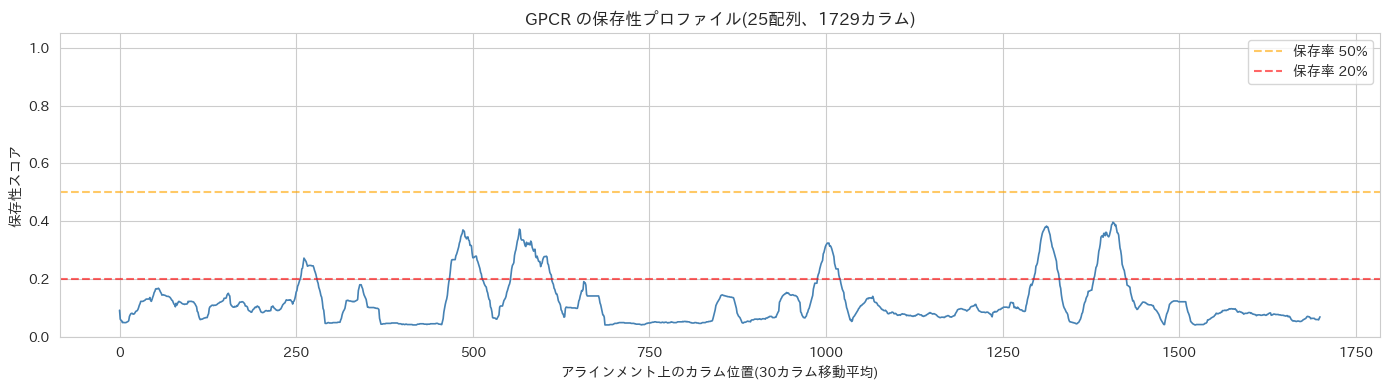


保存率 ≥ 50% のカラム: 51 / 1729 (2.9%)


In [14]:
if mafft_alignment is not None:
    aln_array = np.array([list(str(rec.seq).upper()) for rec in mafft_alignment])
    n_seqs, n_cols = aln_array.shape

    conservation = np.zeros(n_cols)
    for j in range(n_cols):
        col = aln_array[:, j]
        col_no_gap = col[col != "-"]
        if len(col_no_gap) > 0:
            _, counts = np.unique(col_no_gap, return_counts=True)
            # ギャップだらけの列を過大評価しないよう、全配列数で正規化
            conservation[j] = counts.max() / n_seqs

    window = 30
    smoothed = np.convolve(conservation, np.ones(window) / window, mode="valid")

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(range(len(smoothed)), smoothed, color="steelblue", linewidth=1.2)
    ax.axhline(0.5, color="orange", linestyle="--", alpha=0.6, label="保存率 50%")
    ax.axhline(0.2, color="red", linestyle="--", alpha=0.6, label="保存率 20%")
    ax.set_xlabel(f"アラインメント上のカラム位置({window}カラム移動平均)")
    ax.set_ylabel("保存性スコア")
    ax.set_title(f"GPCR の保存性プロファイル({n_seqs}配列、{n_cols}カラム)")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(f"\n保存率 ≥ 50% のカラム: {(conservation >= 0.5).sum()} / {n_cols} "
          f"({100*(conservation >= 0.5).mean():.1f}%)")
else:
    print("MAFFT 結果がないため、このセルはスキップします。")

### 9.5 IQ-TREEによる最尤系統樹の推定

In [15]:
ml_treefile = Path(str(aligned_path) + ".treefile")

if iqtree_cmd and aligned_path.exists():
    help_out = subprocess.run([iqtree_cmd, "--help"], capture_output=True, text=True)
    help_text = help_out.stdout + help_out.stderr
    is_modern = ("-B NUM" in help_text) or ("--prefix" in help_text)

    bootstrap_args = ["-B", "1000"] if is_modern else ["-bb", "1000"]
    threads_args = ["-T", "AUTO"] if is_modern else ["-nt", "AUTO"]
    print(f"IQ-TREE バージョン: {'v2/v3 系' if is_modern else 'v1 系'}")

    print("IQ-TREE を実行中(数十秒〜数分)...")
    proc = subprocess.run(
        [iqtree_cmd, "-s", str(aligned_path), "-m", "MFP",
         *bootstrap_args, *threads_args, "-redo"],
        capture_output=True, text=True,
    )
    if proc.returncode == 0:
        print("IQ-TREE 完了")
        print("\n生成されたファイル:")
        for f in sorted(WORK_DIR.glob("gpcr_aligned.fasta.*")):
            print(f"  {f.name}")
    else:
        print(f"IQ-TREE がエラー終了しました:\n{proc.stderr[-500:]}")
else:
    print("IQ-TREE またはアラインメントが無いため、スキップします。")

IQ-TREE バージョン: v2/v3 系
IQ-TREE を実行中(数十秒〜数分)...
IQ-TREE 完了

生成されたファイル:
  gpcr_aligned.fasta.bionj
  gpcr_aligned.fasta.ckp.gz
  gpcr_aligned.fasta.contree
  gpcr_aligned.fasta.iqtree
  gpcr_aligned.fasta.log
  gpcr_aligned.fasta.mldist
  gpcr_aligned.fasta.model.gz
  gpcr_aligned.fasta.splits.nex
  gpcr_aligned.fasta.treefile


### 9.6 採用されたモデルを確認

ModelFinder は何十種類ものアミノ酸置換モデルから AIC/BIC で最良のものを選びます
(タンパク質では LG・WAG・JTT などが代表的)。`.iqtree` レポートで採用モデルを確認します。

In [16]:
report_file = Path(str(aligned_path) + ".iqtree")
if report_file.exists():
    text = report_file.read_text()
    for keyword in ["Best-fit model", "Model of substitution",
                    "Log-likelihood of the tree",
                    "Akaike information criterion (AIC) score",
                    "Bayesian information criterion (BIC) score"]:
        for line in text.splitlines():
            if keyword in line:
                print(line.strip())
                break
else:
    print("IQ-TREE レポートがないため、このセルはスキップします。")

Best-fit model according to BIC: PMB+I+G4
Model of substitution: PMB+I+G4
Log-likelihood of the tree: -30102.3968 (s.e. 770.1629)
Akaike information criterion (AIC) score: 60302.7935
Bayesian information criterion (BIC) score: 60570.1031


### 9.7 ML 系統樹の読み込みと描画

IQ-TREE の出力 `.treefile`(Newick 形式)を Biopython で読み込みます。
NJ と同じく明確な外群がないので **中点ルーティング** を使い、
内部ノードラベルに入っている **ブートストラップ支持率 (0〜100)** を取り出します。

In [17]:
def load_ml_tree(path):
    tree = Phylo.read(path, "newick")
    tree.root_at_midpoint()
    for clade in tree.get_nonterminals():
        if clade.name:
            try:
                clade.confidence = float(clade.name)
            except ValueError:
                pass
        clade.name = None
    return tree

if ml_treefile.exists():
    ml_tree = load_ml_tree(ml_treefile)
    bs_values = [c.confidence for c in ml_tree.get_nonterminals()
                 if c.confidence is not None]
    print("ML 系統樹を読み込みました")
    print(f"  末端: {ml_tree.count_terminals()}")
    if bs_values:
        print(f"  ブートストラップ支持率: 平均 {np.mean(bs_values):.1f}, "
              f"範囲 [{min(bs_values):.0f}, {max(bs_values):.0f}]")
        print(f"  ≥ 95(強い支持)の枝: {sum(b >= 95 for b in bs_values)} / {len(bs_values)}")
else:
    print("ML 系統樹ファイルがないため、このセルはスキップします。")
    ml_tree = None

ML 系統樹を読み込みました
  末端: 25
  ブートストラップ支持率: 平均 79.0, 範囲 [12, 100]
  ≥ 95(強い支持)の枝: 9 / 22


### 9.8 ML 系統樹をブートストラップ支持率付きで描画

各内部ノードに **ブートストラップ値** を表示します。

- 🟢 緑 (≥ 95): 強い支持(その枝はほぼ確実)
- 🟠 橙 (70–94): 中程度の支持
- 🔴 赤 (< 70): 弱い支持(その枝は信頼できない)

**支持率の低い枝は、データだけからは「どちらが正しいか決められなかった」**ことを意味します。

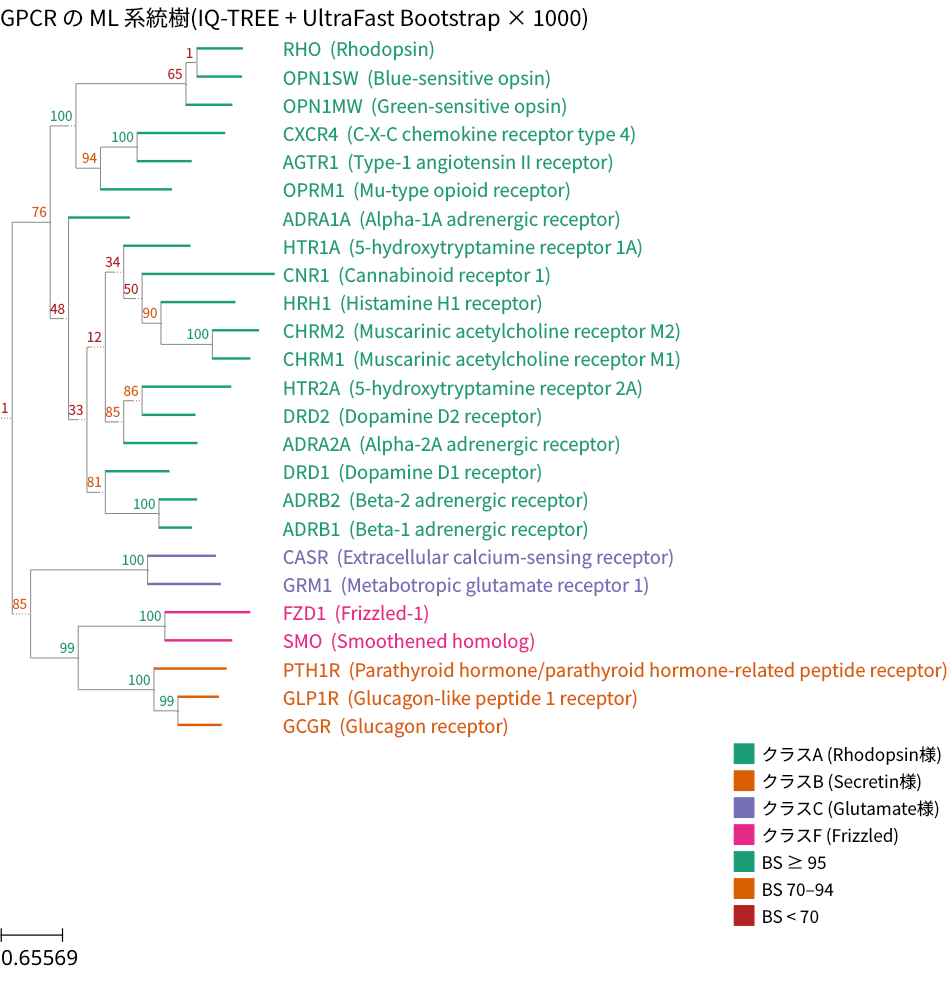

In [18]:
if ml_tree is not None:
    draw_tree_ete(ml_tree,
                  "GPCR の ML 系統樹(IQ-TREE + UltraFast Bootstrap × 1000)",
                  show_bootstrap=True)
else:
    print("ML 系統樹がないため、このセルはスキップします。")

### 9.9 NJ と ML を並べて比較

同じデータから 2 つの方法で系統樹を作りました。並べて見比べてみましょう。

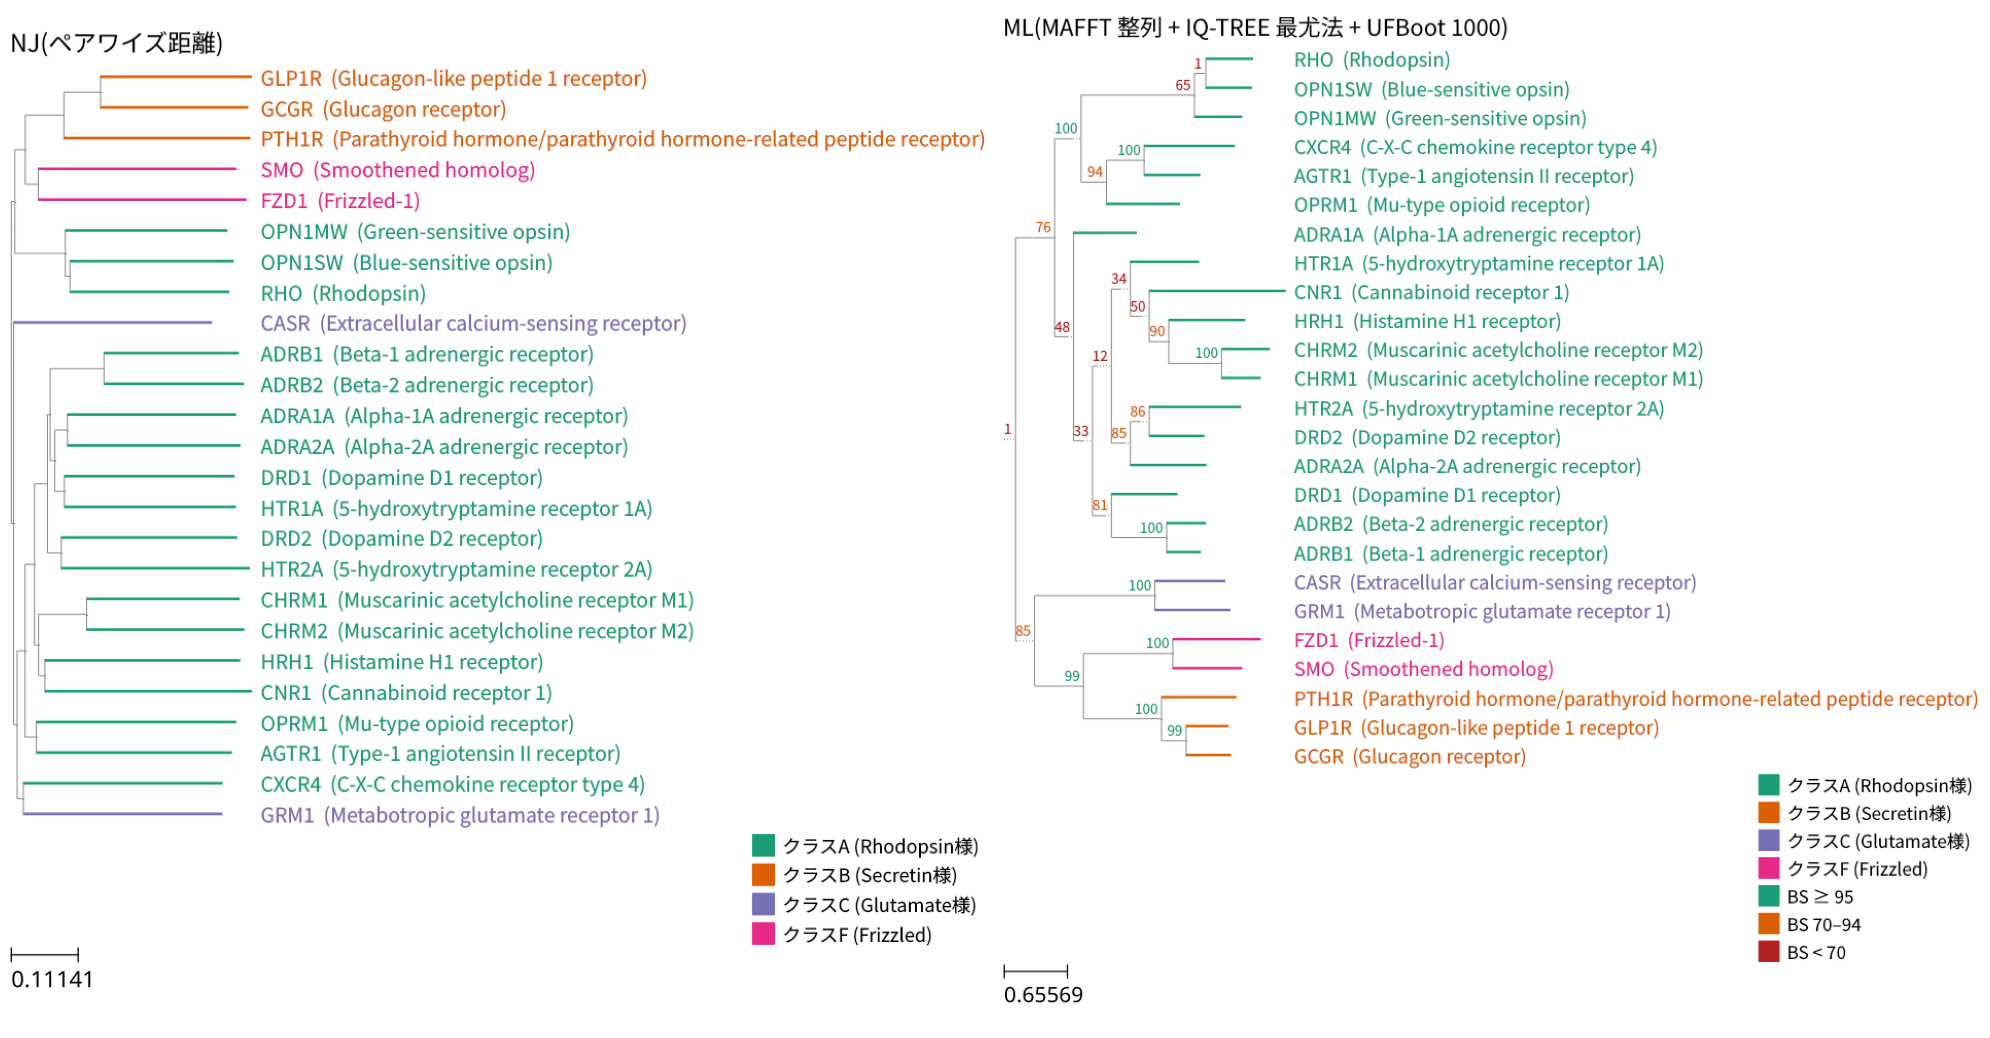

In [19]:
if ml_tree is not None:
    tmp = Path(tempfile.gettempdir())
    png_nj = render_ete_to_png(nj_tree, "NJ(ペアワイズ距離)",
                               out_path=tmp / "gpcr_cmp_nj.png")
    png_ml = render_ete_to_png(ml_tree, "ML(MAFFT 整列 + IQ-TREE 最尤法 + UFBoot 1000)",
                               show_bootstrap=True, out_path=tmp / "gpcr_cmp_ml.png")
    fig, axes = plt.subplots(1, 2, figsize=(20, 11))
    for ax, png in zip(axes, [png_nj, png_ml]):
        ax.imshow(mpimg.imread(png)); ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("ML 系統樹がないため比較できません。")

**比較の観察ポイント**

- **大枠のクラス分け(A / B / C / F)** が両者で一致していれば、それは信頼できるシグナル
- **クラス A 内部の細かい枝**は方法によって少し違うことがある。ML 樹でその枝のブートストラップが低ければ、「データだけでは決められない部分」だったということ
- **枝の長さ**は ML のほうが情報量が多い(置換モデルでの推定値)── 同じ短い枝でも「ほとんど変わっていない」のか「最近分かれた」のかを区別できる

## 10. 立体構造を眺めてみる

このデータセットには各受容体の **AlphaFold 予測立体構造**(`gpcr/pdb/`)も入っています。
配列はクラス間で大きく違っても、**「7回膜貫通」という骨格は共通**しているはずです。
`py3Dmol` がインストールされていれば、ノートブック内で 3D 構造をくるくる回して確認できます。

> 配列の系統樹で「遠い」とされた受容体どうしでも、立体構造の骨格は似ている ──
> これは **構造のほうが配列より進化的に保存されやすい** という重要な性質の表れです。

In [20]:
# py3Dmol が無ければ以下を実行: 
%pip install py3Dmol

try:
    import py3Dmol

    def show_structure(gene, color):
        pdb_files = list(PDB_DIR.glob(f"{gene}_*.pdb"))
        if not pdb_files:
            print(f"{gene} の PDB が見つかりません")
            return None
        view = py3Dmol.view(width=350, height=350)
        view.addModel(pdb_files[0].read_text(), "pdb")
        view.setStyle({"cartoon": {"color": color}})
        view.zoomTo()
        return view

    # クラス A(ロドプシン)とクラス C(代謝型グルタミン酸受容体)を見比べる
    print("RHO (クラスA, 348残基) ─ コンパクトな7回膜貫通")
    v1 = show_structure("RHO", "spectrum")
    if v1: v1.show()
    print("GRM1 (クラスC, 906残基) ─ 巨大な細胞外ドメイン + 7回膜貫通")
    v2 = show_structure("GRM1", "spectrum")
    if v2: v2.show()
except ImportError:
    print("py3Dmol が未インストールです。`%pip install py3Dmol` で導入すると 3D 表示できます。")
    print(f"PDB ファイルは {PDB_DIR} に {len(list(PDB_DIR.glob('*.pdb')))} 個あります。")

Note: you may need to restart the kernel to use updated packages.
RHO (クラスA, 348残基) ─ コンパクトな7回膜貫通


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

GRM1 (クラスC, 906残基) ─ 巨大な細胞外ドメイン + 7回膜貫通


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## 11. 発展編 — 立体構造に基づく系統樹推定

ここまでは **配列(文字列)** を比べてきました。しかし GPCR のようにクラス間で大きく分岐したファミリーでは、
揃えられるのは保存された膜貫通領域が中心で、アラインメント自体に不確実性が残りました。

> **アイデア:** タンパク質の **立体構造は配列よりも進化的に保存されやすい**。
> ならば、配列を揃える代わりに **構造そのものを重ね合わせて**、似ているかどうかを測れば、
> 配列ではぼやけてしまう遠縁の関係も捉えられるかもしれません。

**手順**

1. 各受容体の AlphaFold 構造(`gpcr/pdb/`)を **総当たり**で重ね合わせる(構造アラインメント)
2. 重なり具合を **TM-score**(0〜1、1 に近いほど同じ折りたたみ。おおむね 0.5 以上で「同じフォールド」)で数値化
3. **構造距離** $d = 1 - \mathrm{TMscore}$ を距離行列にして **NJ 法** で系統樹を作る
4. **配列の系統樹**と並べて、どこが一致し、どこが違うかを観察する

ここでは TM-align の Python 実装 **`tmtools`** を使います。
研究現場では **Foldseek / FoldTree / US-align / DALI** などがこの目的で広く使われています。

### 11.1 tmtools の準備

構造アラインメント用ライブラリ `tmtools`(TM-align の Python 実装)をインストールします。
構造の読み込みには既に入っている Biopython を使います。

In [21]:
# 初回のみ(未インストールなら下のコメントを外す)
%pip install tmtools

try:
    from tmtools import tm_align
    from tmtools.io import get_structure, get_residue_data
    tmtools_available = True
    print("tmtools: OK")
except ImportError:
    tmtools_available = False
    print("tmtools が未インストールです。`%pip install tmtools` を実行してください。")
    print("このセクションはスキップされます(系統樹は配列ベースの結果のみ)。")

Note: you may need to restart the kernel to use updated packages.
tmtools: OK


### 11.2 構造の読み込みと総当たり構造比較

各 PDB ファイルから **Cα 原子の座標**と配列を取り出し、すべてのペアを TM-align で重ね合わせます。

TM-score は **短いほうの鎖で正規化** されるため、長さが違うと A→B と B→A で値が変わります(非対称)。
そこで **両方向の平均**を「構造類似度」とし、対称な距離行列を作ります。

> 25 構造 → 300 ペアの重ね合わせで、**おおよそ 2〜5 分**かかります(クラス C の巨大構造を含むため)。

In [22]:
if tmtools_available and PDB_DIR.exists():
    # PDB から Cα 座標と配列を取得(ファイル名 ADRB2_AF-P07550.pdb -> 遺伝子名 ADRB2)
    struct_data = {}
    for pdb_path in sorted(PDB_DIR.glob("*.pdb")):
        gene = pdb_path.stem.split("_")[0]
        structure = get_structure(str(pdb_path))
        chain = next(structure.get_chains())
        coords, seq = get_residue_data(chain)
        struct_data[gene] = (coords, seq)
    struct_genes = sorted(struct_data)
    n_st = len(struct_genes)
    print(f"読み込んだ構造: {n_st}")

    # 総当たり TM-align(上三角だけ計算し、両方向の TM-score を平均して対称化)
    print("構造を総当たりで重ね合わせ中(2〜5分)...")
    sim = np.eye(n_st)
    n_pairs = n_st * (n_st - 1) // 2
    done = 0
    for i in range(n_st):
        ci, si = struct_data[struct_genes[i]]
        for j in range(i + 1, n_st):
            cj, sj = struct_data[struct_genes[j]]
            res = tm_align(ci, cj, si, sj)
            s = (res.tm_norm_chain1 + res.tm_norm_chain2) / 2
            sim[i, j] = sim[j, i] = s
            done += 1
        print(f"  {done}/{n_pairs} ペア完了", end="\r")
    print(f"\n完了。構造類似度行列: {n_st} × {n_st}")

    struct_dist = 1.0 - sim
    np.fill_diagonal(struct_dist, 0.0)

    g2i = {g: k for k, g in enumerate(struct_genes)}
    def sd(a, b):
        return struct_dist[g2i[a], g2i[b]]
    print("\n例(構造距離 = 1 - TMスコア):")
    print(f"  RHO vs OPN1SW (オプシン同士)   = {sd('RHO', 'OPN1SW'):.3f}")
    print(f"  RHO vs CASR  (クラスA vs クラスC) = {sd('RHO', 'CASR'):.3f}  ← 配列距離より近いことが多い")
    print(f"  SMO vs FZD1  (クラスF同士)      = {sd('SMO', 'FZD1'):.3f}")
else:
    print("tmtools または PDB フォルダが無いため、このセクションはスキップします。")
    struct_dist = None

読み込んだ構造: 25
構造を総当たりで重ね合わせ中(2〜5分)...
  300/300 ペア完了
完了。構造類似度行列: 25 × 25

例(構造距離 = 1 - TMスコア):
  RHO vs OPN1SW (オプシン同士)   = 0.088
  RHO vs CASR  (クラスA vs クラスC) = 0.585  ← 配列距離より近いことが多い
  SMO vs FZD1  (クラスF同士)      = 0.525


### 11.3 構造類似度のヒートマップ

配列距離のヒートマップ(セクション6)と見比べてみましょう。
構造のほうが、クラスをまたいでも全体に「近い」(=同じ7回膜貫通フォールドを共有する)ことが見えるはずです。

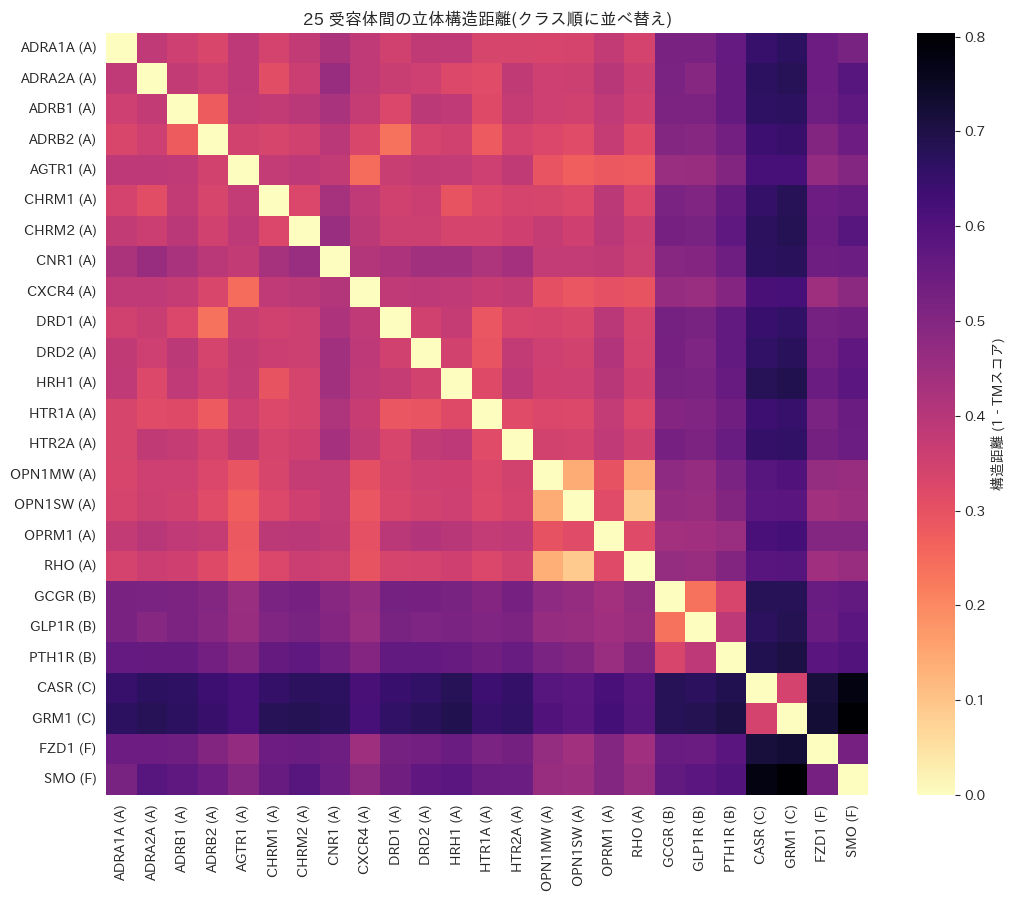

In [23]:
if struct_dist is not None:
    sdf = pd.DataFrame(struct_dist, index=struct_genes, columns=struct_genes)
    ordered_st = sorted(struct_genes,
                        key=lambda g: (class_order.index(gene_to_class[g]), g))
    sdf = sdf.loc[ordered_st, ordered_st]
    labels_st = [f"{g} ({gene_to_class[g]})" for g in sdf.index]

    fig, ax = plt.subplots(figsize=(11, 9))
    sns.heatmap(sdf, cmap="magma_r",
                xticklabels=labels_st, yticklabels=labels_st,
                cbar_kws={"label": "構造距離 (1 - TMスコア)"}, ax=ax, square=True)
    ax.set_title("25 受容体間の立体構造距離(クラス順に並べ替え)")
    plt.tight_layout()
    plt.show()
else:
    print("構造距離が無いため、このセルはスキップします。")

### 11.4 構造に基づく系統樹(NJ法)

構造距離行列から NJ 法で系統樹を作り、配列の樹と同じくクラスで色分けして描画します。

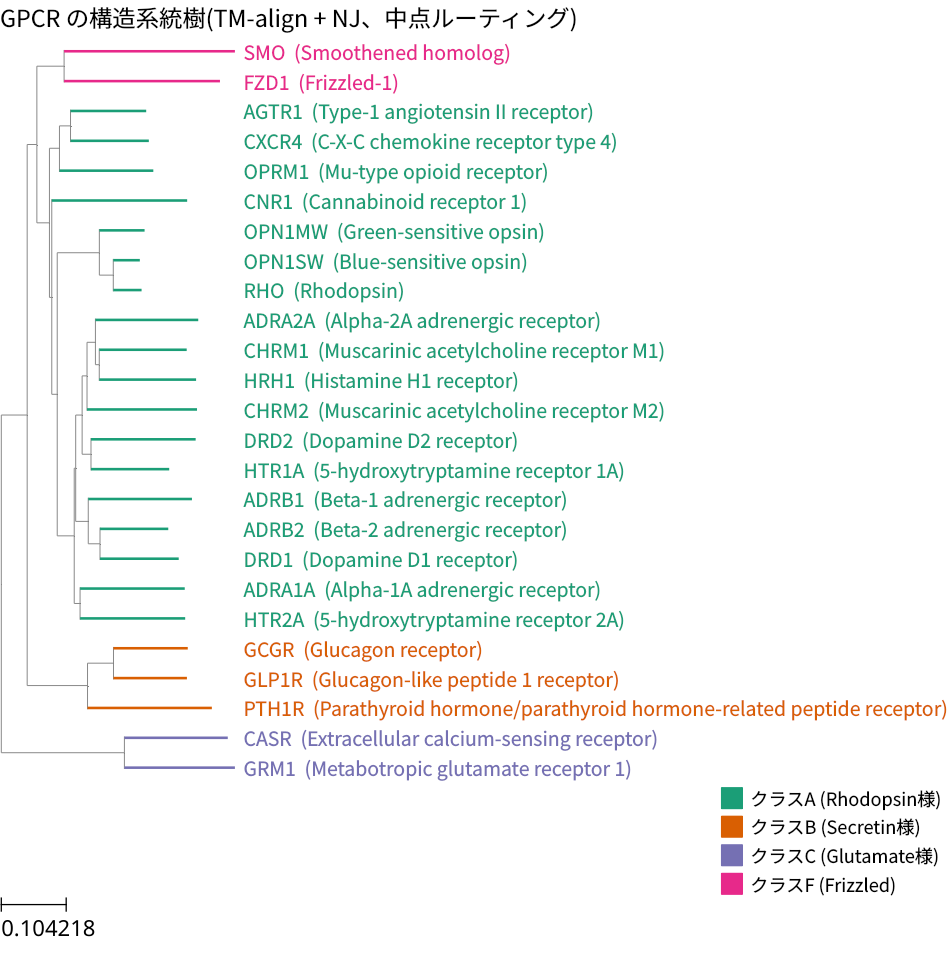

In [24]:
if struct_dist is not None:
    lower_st = [[struct_dist[i, j] for j in range(i + 1)] for i in range(n_st)]
    struct_dm = DistanceMatrix(struct_genes, lower_st)
    struct_tree = DistanceTreeConstructor().nj(struct_dm)
    struct_tree.root_at_midpoint()
    for clade in struct_tree.get_nonterminals():
        clade.name = None

    draw_class_tree(struct_tree,
                    "GPCR の構造系統樹(TM-align + NJ、中点ルーティング)",
                    xlabel="構造距離 (1 - TMスコア)")
else:
    print("構造距離が無いため、このセルはスキップします。")
    struct_tree = None

### 11.5 配列の樹 vs 構造の樹

同じ 25 受容体について、**配列**から作った樹と **立体構造**から作った樹を並べます。
(配列側は、最尤樹があればそれを、無ければ入門編の NJ 樹を使います。)

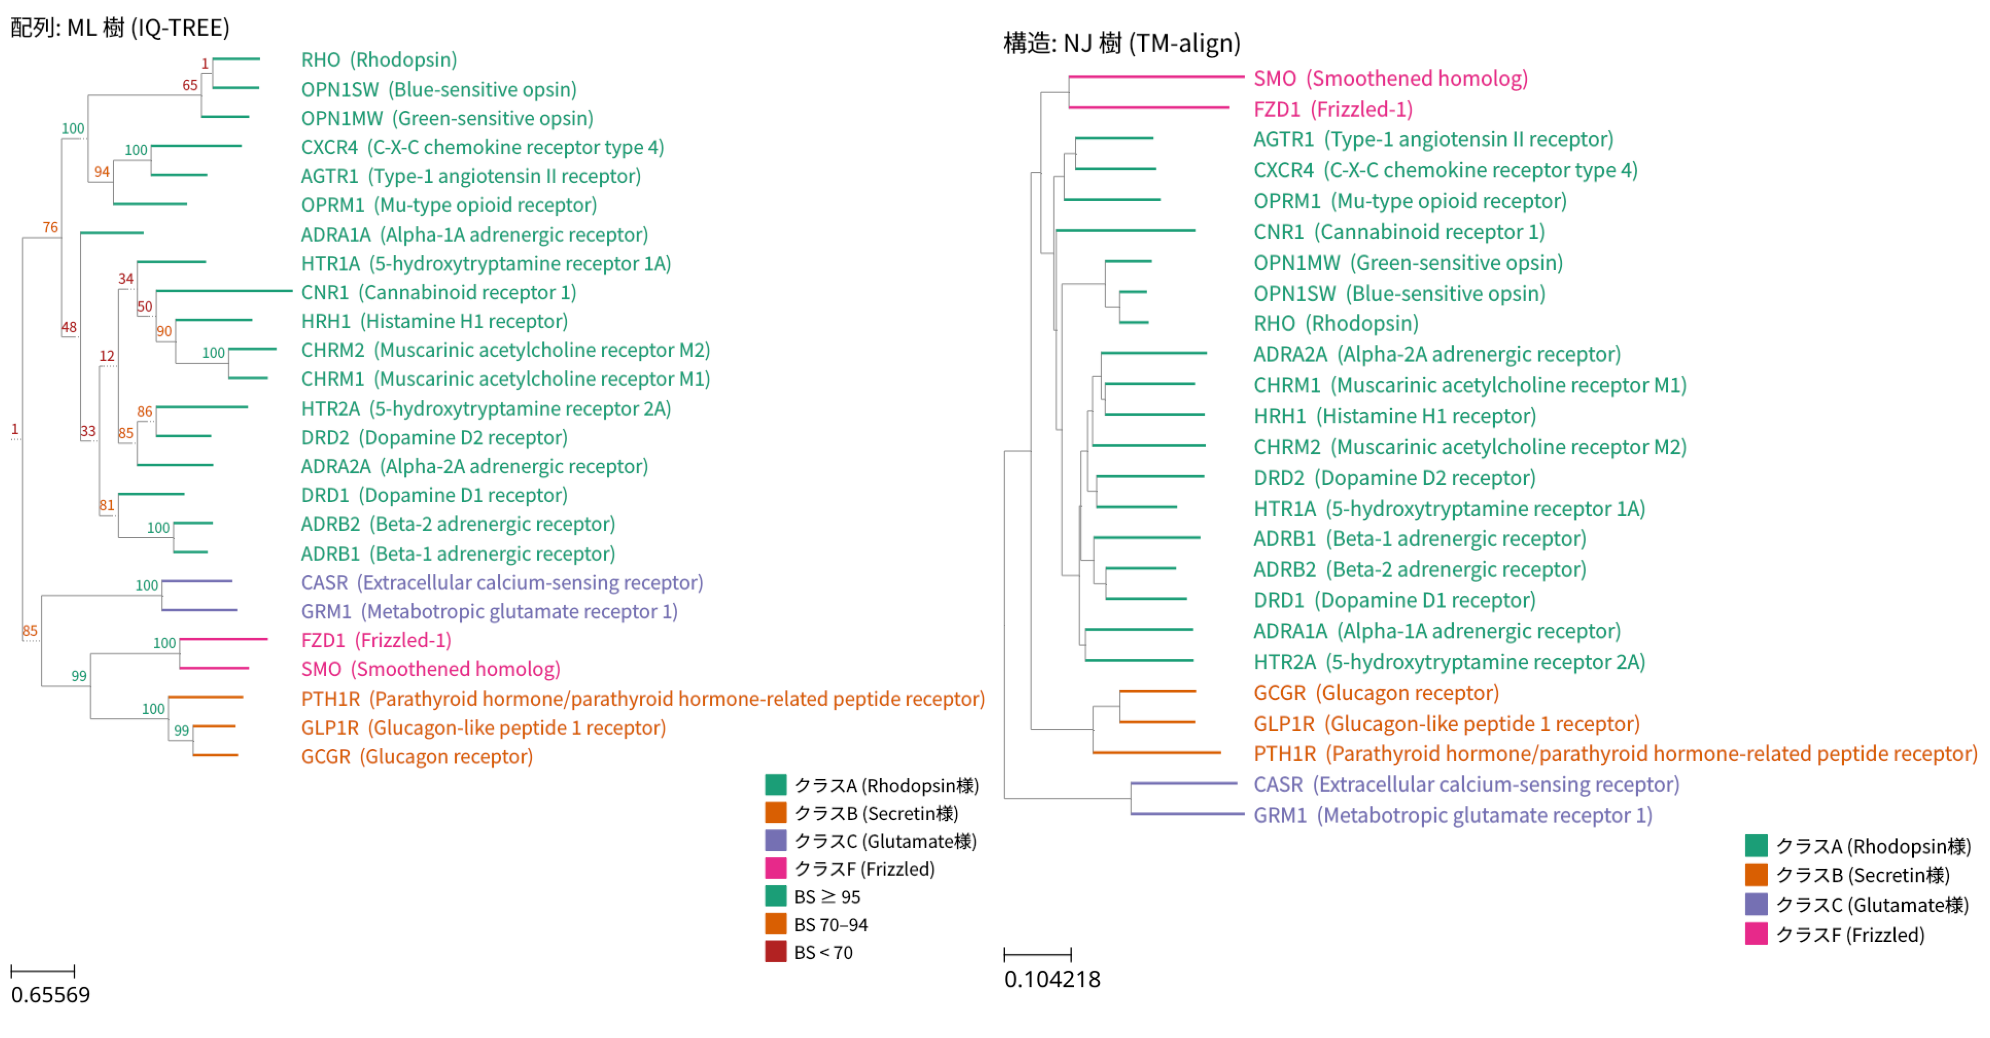

In [25]:
if struct_tree is not None:
    seq_tree = ml_tree if ("ml_tree" in dir() and ml_tree is not None) else nj_tree
    seq_label = ("配列: ML 樹 (IQ-TREE)" if seq_tree is ml_tree
                 else "配列: NJ 樹(ペアワイズ距離)")
    tmp = Path(tempfile.gettempdir())
    png_seq = render_ete_to_png(seq_tree, seq_label,
                                show_bootstrap=(seq_tree is ml_tree),
                                out_path=tmp / "gpcr_seq.png")
    png_struct = render_ete_to_png(struct_tree, "構造: NJ 樹 (TM-align)",
                                   out_path=tmp / "gpcr_struct.png")
    fig, axes = plt.subplots(1, 2, figsize=(20, 11))
    for ax, png in zip(axes, [png_seq, png_struct]):
        ax.imshow(mpimg.imread(png)); ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("構造系統樹が無いため比較できません。")

**比較の観察ポイント**

- **クラスの大枠(A/B/C/F)** は配列でも構造でも分かれているはず → どちらの情報にも強く刻まれた進化の信号
- **クラスをまたぐ距離**は構造のほうが小さい(=全体に似て見える)。これは「7回膜貫通」という共通フォールドが保存されているため
- **配列ではあいまいだった枝**が構造ではすっきり分かれる(またはその逆)ことがある。どの受容体で食い違うか探してみよう
- 配列と構造が食い違う部分は、**進化の途中で配列は大きく変わったが折りたたみは保たれた**(またはその逆)ことを示唆する

## 12. 考察 — 系統樹は何を語っているか

### Q1. GPCR の4クラス（A/B/C/F）は再現できた?

配列だけから作った樹で、クラス B(GCGR, GLP1R, PTH1R)・C(GRM1, CASR)・F(SMO, FZD1)はそれぞれ1つの枝にまとまりましたか？それを支える枝のブートストラップ支持率は?

### Q2. 機能グループと系統関係

クラス A はヒト GPCR の大半を占める巨大グループです。その内部を見ると…

- **オプシン**（RHO, OPN1SW, OPN1MW）── 光を受容
- **アミン受容体**（ADRB1/2, ADRA1A/2A, DRD1/2, HTR1A/2A, CHRM1/2, HRH1）── アドレナリン・ドーパミン・セロトニン・ヒスタミン・アセチルコリンなどの **小さなアミン分子** を受容
- **ペプチド/脂質受容体**（OPRM1, CNR1, AGTR1, CXCR4）── 大きめのリガンドを受容

こういった「同じ種類のリガンドを受容する受容体」は系統的にも近い傾向が見えたでしょうか？

一方で、機能が似ていても系統的に遠い例は見つかりましたか？

- クラスBの **GLP1R / GCGR / PTH1R** はすべてペプチドホルモン受容体ですが、クラス A のペプチド受容体(OPRM1 など)とは系統的に遠いはずです。「ペプチドを受容する」という機能は、収斂進化の可能性があります。
- クラスFの **SMO/FZD1** は発生シグナルに関わり、他クラスとは大きく離れています。

### Q3. 枝の長さをじっくりみてみよう

例えば、クラスCの受容体（GRM1, CASR）は長い枝の先に位置しますね。これは「他クラスから早く分かれ、独自に大きく変化した」ことを示唆します。他のクラスはどうでしょうか。

### Q4. ブートストラップ支持率が低い枝はなぜ低い?

支持率が低くなる要因としては、一般的に以下が考えられます。今回はどのケースに該当するでしょうか？
- 配列に含まれる「系統の信号」が弱い（短期間に複数系統が連続して分かれた等）
- アラインメントできる保存領域が短い
- 進化速度が極端に違う系統が混じる → 長枝誘引（long branch attraction）

### Q5. 配列の樹と構造の樹はどこが違った?

- 大枠のクラス分け(A/B/C/F)は **両方で一致**していましたか?
- **一致しなかった枝**はどこ? その受容体は「配列は大きく変わったが折りたたみは保たれた」のか、それとも「予測構造の不確実な領域に引っ張られた」のか、どちらだと思いますか?
- 配列・構造・機能(リガンドの種類)の3つの情報が **そろって支持する**関係は、最も信頼できる進化的シグナルと言えます。今回そのような関係はありましたか?